In [31]:
import os
import polars as pl
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Dane
#### Wczytanie danych

In [32]:
file_path = str(Path.home() / "Desktop" / "Hackaton VISA" / "datasprint_sample_data.parquet")

### Wszytskie transakcje w Krakowie

In [33]:
city = 'KRAKOW%'
flag = 1

In [34]:
df_krakow = duckdb.sql(f""" SELECT 
    tran_id_raw,  
    pymt_crd_acct_num_raw, 
    transaction_type, 
    upper(mrch_nm_raw) as mrch_nm_raw, 
    mrch_catg_cd, 
    mrch_catg_nm, 
    mrch_city_nm_raw,
    mrch_postal_code, 
    cs_tran_amt, 
    prch_mnth_id, 
    prch_dt,
    tran_id_gmt_tm
    
    FROM '{file_path}' WHERE prod_id_pltfrm_cd_vcis = 'CN' and cp_flag = {flag} and mrch_city_nm_raw LIKE '{city}'""").to_df() 

In [35]:
df_krakow.head()

,tran_id_raw,pymt_crd_acct_num_raw,transaction_type,mrch_nm_raw,mrch_catg_cd,mrch_catg_nm,mrch_city_nm_raw,mrch_postal_code,cs_tran_amt,prch_mnth_id,prch_dt,tran_id_gmt_tm
0,974298192,72f97cee703ab09d7127e5995a422d107a8707fbb4320cb,POS,ZABKA ZB263 K.1,5499,MISC FOOD STORES - DEFAULT,KRAKOW,31-476,139.04880,202506,2025-06-19,143200
1,974751128,4cf266a05a8f23b67bb8cf1f4ec4780120ca06616ddc020,POS,PIEKARNIA U BRACI,5462,BAKERIES,KRAKOW,31-625,160.74240,202507,2025-07-31,102223
2,974751357,d318243e56ac2b8a967413547b8dc321d1c5bed3bf9235c,POS,OYSHO BONARKA 16044,5691,MENS/WOMENS CLOTHING STORES,KRAKOW,31-625,363.30800,202507,2025-07-25,164543
3,974751421,8bcdf72ae320e4e53140ad06840abfd709b982a99dbea25,POS,DM-DROGERIE MARKT 022,5912,DRUG STORES & PHARMACIES,KRAKOW,31-801,92.39560,202507,2025-07-03,142106
4,974751580,c0896b8b90728a38562c964d3e1b4932b4ab96d11689fec,NA,LPP RESERVED 1912217,5651,FAMILY CLOTHING STORES,KRAKOW,31-123,154.54344,202507,2025-07-23,132850


### Transakcje biletowe

In [36]:
df_tickets = df_krakow[
    df_krakow["mrch_catg_cd"] == 4111
].copy()

In [37]:
df_tickets.head()

,tran_id_raw,pymt_crd_acct_num_raw,transaction_type,mrch_nm_raw,mrch_catg_cd,mrch_catg_nm,mrch_city_nm_raw,mrch_postal_code,cs_tran_amt,prch_mnth_id,prch_dt,tran_id_gmt_tm
20,977145695,eace9da070ad28a44f6dec14d0515fc3641da4eecf0dfdd,POS,MPK KRAKOW KKM 160,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,30-347,14.352,202510,2025-10-20,071715
48,671111991,5e8b1d8e6895414b5544f8efd21052d051fc945f863f115,POS,KASOWNIK ZTP KRAKOW K1612,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,31-625,6.992,202512,2025-12-16,104743
69,354053304,b48c046632e5f8642e029d7613682196701d771367b2bbf,POS,MPK KRAKOW KKM 133,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,42-202,7.728,202604,2026-04-01,110513
70,354053305,b48c046632e5f8642e029d7613682196701d771367b2bbf,POS,MPK KRAKOW KKM 133,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,42-202,15.456,202604,2026-04-01,110636
128,1212992122,4c2df4bc3c48534ca9cd5926d9c7fdc68360f3043becbf3,POS,MPK KRAKOW KKM 63,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,31-626,41.952,202506,2025-06-15,163217


In [38]:
len(df_tickets)

195747

Dodanie czasu do daty

In [39]:
df_krakow["tran_id_gmt_tm"] = (
    df_krakow["tran_id_gmt_tm"]
    .astype(str)
    .str.zfill(6)
)

df_tickets["tran_id_gmt_tm"] = (
    df_tickets["tran_id_gmt_tm"]
    .astype(str)
    .str.zfill(6)
)

In [40]:
df_krakow["transaction_time"] = pd.to_datetime(
    df_krakow["prch_dt"].astype(str)
    + " "
    + df_krakow["tran_id_gmt_tm"],
    format="%Y-%m-%d %H%M%S"
)

df_tickets["ticket_time"] = pd.to_datetime(
    df_tickets["prch_dt"].astype(str)
    + " "
    + df_tickets["tran_id_gmt_tm"],
    format="%Y-%m-%d %H%M%S"
)

Z tabeli biletowej zostawiamy minimum danych

In [41]:
tickets_for_merge = df_tickets[
    [
        "tran_id_raw",
        "pymt_crd_acct_num_raw",
        "cs_tran_amt",
        "ticket_time"
    ]
].copy()

tickets_for_merge = tickets_for_merge.rename(
    columns={"tran_id_raw": "ticket_tran_id"}
)

In [42]:
tickets_for_merge.head()

,ticket_tran_id,pymt_crd_acct_num_raw,cs_tran_amt,ticket_time
20,977145695,eace9da070ad28a44f6dec14d0515fc3641da4eecf0dfdd,14.352,2025-10-20 07:17:15
48,671111991,5e8b1d8e6895414b5544f8efd21052d051fc945f863f115,6.992,2025-12-16 10:47:43
69,354053304,b48c046632e5f8642e029d7613682196701d771367b2bbf,7.728,2026-04-01 11:05:13
70,354053305,b48c046632e5f8642e029d7613682196701d771367b2bbf,15.456,2026-04-01 11:06:36
128,1212992122,4c2df4bc3c48534ca9cd5926d9c7fdc68360f3043becbf3,41.952,2025-06-15 16:32:17


### Wyznaczanie transakcji po kupienu biletu

In [43]:
df_near_ticket = df_krakow.merge(
    tickets_for_merge,
    on="pymt_crd_acct_num_raw",
    how="inner"
)

In [44]:
df_near_ticket["time_diff"] = (
    df_near_ticket["transaction_time"]
    - df_near_ticket["ticket_time"]
)

In [45]:
df_near_ticket = df_near_ticket[
    df_near_ticket["time_diff"].between(
        pd.Timedelta(minutes=2),
        pd.Timedelta(minutes=120)
    )
]

In [47]:
df_near_ticket["minutes_after_ticket"] = (
    df_near_ticket["time_diff"].dt.total_seconds() // 60
).astype(int)

In [48]:
df_near_ticket = df_near_ticket.sort_values(
    ["ticket_tran_id", "transaction_time"]
)

In [49]:
df_near_ticket = df_near_ticket.rename(
    columns={
        "cs_tran_amt_x": "next_tran_amount",
        "cs_tran_amt_y": "ticket_amount"
    }
)

In [50]:
df_near_ticket.head()

,tran_id_raw,pymt_crd_acct_num_raw,transaction_type,mrch_nm_raw,mrch_catg_cd,mrch_catg_nm,mrch_city_nm_raw,mrch_postal_code,next_tran_amount,prch_mnth_id,prch_dt,tran_id_gmt_tm,transaction_time,ticket_tran_id,ticket_amount,ticket_time,time_diff,minutes_after_ticket
35951732,16429185,75e335ba241be65d798748f92580ecd26a70bfc5edb94b7,POS,FUNDACJA MPIOZ II,7997,MEMBER CLUBS/SPORT/REC/GOLF,KRAKOW,30-232,243.98400,202506,2025-06-24,094245,2025-06-24 09:42:45,32967,20.976,2025-06-24 08:36:48,0 days 01:05:57,65
14756594,691468312,0451cb4f4bc4cedcdcab1af59684b437d23471a4594d386,POS,KASOWNIK ZTP KRAKOW K1606,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,31-625,5.52000,202508,2025-08-04,145146,2025-08-04 14:51:46,59612,2.576,2025-08-04 13:10:58,0 days 01:40:48,100
17671123,1176054255,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,KAUFLAND 04,5411,GROCERY STORES/SUPERMARKETS,KRAKOW,31-123,43.76072,202507,2025-07-17,082108,2025-07-17 08:21:08,111838,1.472,2025-07-17 07:57:34,0 days 00:23:34,23
9390090,559182622,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,PEPCO 110654 KRAKOW 30,5310,DISCOUNT STORES,KRAKOW,31-625,62.56000,202507,2025-07-17,083254,2025-07-17 08:32:54,111838,1.472,2025-07-17 07:57:34,0 days 00:35:20,35
1386298,78824080,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,AUTOMAT,5814,FAST FOOD RESTAURANTS,KRAKOW,31-008,4.36080,202507,2025-07-17,083423,2025-07-17 08:34:23,111838,1.472,2025-07-17 07:57:34,0 days 00:36:49,36


In [51]:
df_near_ticket = df_near_ticket.sort_values(
    ["ticket_tran_id", "transaction_time"]
)

df_near_ticket["event_after_ticket_rank"] = (
    df_near_ticket
    .groupby("ticket_tran_id")
    .cumcount()
    + 1
)

In [52]:
df_near_ticket


,tran_id_raw,pymt_crd_acct_num_raw,transaction_type,mrch_nm_raw,mrch_catg_cd,mrch_catg_nm,mrch_city_nm_raw,mrch_postal_code,next_tran_amount,prch_mnth_id,prch_dt,tran_id_gmt_tm,transaction_time,ticket_tran_id,ticket_amount,ticket_time,time_diff,minutes_after_ticket,event_after_ticket_rank
35951732,16429185,75e335ba241be65d798748f92580ecd26a70bfc5edb94b7,POS,FUNDACJA MPIOZ II,7997,MEMBER CLUBS/SPORT/REC/GOLF,KRAKOW,30-232,243.98400,202506,2025-06-24,094245,2025-06-24 09:42:45,32967,20.976,2025-06-24 08:36:48,0 days 01:05:57,65,1
14756594,691468312,0451cb4f4bc4cedcdcab1af59684b437d23471a4594d386,POS,KASOWNIK ZTP KRAKOW K1606,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,31-625,5.52000,202508,2025-08-04,145146,2025-08-04 14:51:46,59612,2.576,2025-08-04 13:10:58,0 days 01:40:48,100,1
17671123,1176054255,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,KAUFLAND 04,5411,GROCERY STORES/SUPERMARKETS,KRAKOW,31-123,43.76072,202507,2025-07-17,082108,2025-07-17 08:21:08,111838,1.472,2025-07-17 07:57:34,0 days 00:23:34,23,1
9390090,559182622,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,PEPCO 110654 KRAKOW 30,5310,DISCOUNT STORES,KRAKOW,31-625,62.56000,202507,2025-07-17,083254,2025-07-17 08:32:54,111838,1.472,2025-07-17 07:57:34,0 days 00:35:20,35,2
1386298,78824080,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,AUTOMAT,5814,FAST FOOD RESTAURANTS,KRAKOW,31-008,4.36080,202507,2025-07-17,083423,2025-07-17 08:34:23,111838,1.472,2025-07-17 07:57:34,0 days 00:36:49,36,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10903966,1356706465,aae11249f5f7011533d99ed73c5de741a9251a3d50f0823,POS,TEDI 7273,5311,DEPARTMENT STORES,KRAKOW,31-625,47.84000,202601,2026-01-19,095212,2026-01-19 09:52:12,1526904693,14.352,2026-01-19 08:43:41,0 days 01:08:31,68,2
30125864,1213618641,aae11249f5f7011533d99ed73c5de741a9251a3d50f0823,POS,KIK TEXTIL SP. Z O.O.,5621,WOMENS READY TO WEAR STORES,KRAKOW,31-277,73.41600,202601,2026-01-19,101221,2026-01-19 10:12:21,1526904693,14.352,2026-01-19 08:43:41,0 days 01:28:40,88,3
12820831,689370649,efec78db88114ae4a1593115c3cbe4f8267a710c25e4573,POS,JMP S.A. BIEDRONKA 5197,5411,GROCERY STORES/SUPERMARKETS,KRAKOW,31-123,22.30632,202604,2026-04-03,084413,2026-04-03 08:44:13,1526945148,6.624,2026-04-03 08:22:09,0 days 00:22:04,22,1
8349347,1479268945,efec78db88114ae4a1593115c3cbe4f8267a710c25e4573,POS,SZWAGROPOL,4131,BUS LINES,KRAKOW,31-625,70.84000,202604,2026-04-03,094731,2026-04-03 09:47:31,1526945148,6.624,2026-04-03 08:22:09,0 days 01:25:22,85,2


In [53]:
df_ticket_followups = df_near_ticket[
    df_near_ticket["event_after_ticket_rank"] <= 5
].copy()

In [24]:
df_ticket_followups

,tran_id_raw,pymt_crd_acct_num_raw,transaction_type,mrch_nm_raw,mrch_catg_cd,mrch_catg_nm,mrch_city_nm_raw,mrch_postal_code,next_tran_amount,prch_mnth_id,prch_dt,tran_id_gmt_tm,transaction_time,ticket_tran_id,ticket_amount,ticket_time,time_diff,minutes_after_ticket,event_after_ticket_rank
35951732,16429185,75e335ba241be65d798748f92580ecd26a70bfc5edb94b7,POS,FUNDACJA MPIOZ II,7997,MEMBER CLUBS/SPORT/REC/GOLF,KRAKOW,30-232,243.98400,202506,2025-06-24,094245,2025-06-24 09:42:45,32967,20.976,2025-06-24 08:36:48,0 days 01:05:57,65,1
14756594,691468312,0451cb4f4bc4cedcdcab1af59684b437d23471a4594d386,POS,KASOWNIK ZTP KRAKOW K1606,4111,LOCAL COMMUTER TRANSPORT,KRAKOW,31-625,5.52000,202508,2025-08-04,145146,2025-08-04 14:51:46,59612,2.576,2025-08-04 13:10:58,0 days 01:40:48,100,1
17671123,1176054255,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,KAUFLAND 04,5411,GROCERY STORES/SUPERMARKETS,KRAKOW,31-123,43.76072,202507,2025-07-17,082108,2025-07-17 08:21:08,111838,1.472,2025-07-17 07:57:34,0 days 00:23:34,23,1
9390090,559182622,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,PEPCO 110654 KRAKOW 30,5310,DISCOUNT STORES,KRAKOW,31-625,62.56000,202507,2025-07-17,083254,2025-07-17 08:32:54,111838,1.472,2025-07-17 07:57:34,0 days 00:35:20,35,2
1386298,78824080,2a7e6ff1cf5c2cc0047367d0ed598f093e0c91f1d20def7,POS,AUTOMAT,5814,FAST FOOD RESTAURANTS,KRAKOW,31-008,4.36080,202507,2025-07-17,083423,2025-07-17 08:34:23,111838,1.472,2025-07-17 07:57:34,0 days 00:36:49,36,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10903966,1356706465,aae11249f5f7011533d99ed73c5de741a9251a3d50f0823,POS,TEDI 7273,5311,DEPARTMENT STORES,KRAKOW,31-625,47.84000,202601,2026-01-19,095212,2026-01-19 09:52:12,1526904693,14.352,2026-01-19 08:43:41,0 days 01:08:31,68,2
30125864,1213618641,aae11249f5f7011533d99ed73c5de741a9251a3d50f0823,POS,KIK TEXTIL SP. Z O.O.,5621,WOMENS READY TO WEAR STORES,KRAKOW,31-277,73.41600,202601,2026-01-19,101221,2026-01-19 10:12:21,1526904693,14.352,2026-01-19 08:43:41,0 days 01:28:40,88,3
12820831,689370649,efec78db88114ae4a1593115c3cbe4f8267a710c25e4573,POS,JMP S.A. BIEDRONKA 5197,5411,GROCERY STORES/SUPERMARKETS,KRAKOW,31-123,22.30632,202604,2026-04-03,084413,2026-04-03 08:44:13,1526945148,6.624,2026-04-03 08:22:09,0 days 00:22:04,22,1
8349347,1479268945,efec78db88114ae4a1593115c3cbe4f8267a710c25e4573,POS,SZWAGROPOL,4131,BUS LINES,KRAKOW,31-625,70.84000,202604,2026-04-03,094731,2026-04-03 09:47:31,1526945148,6.624,2026-04-03 08:22:09,0 days 01:25:22,85,2


first non transport

In [59]:
first_non_transport = (
    df_ticket_followups[
        df_ticket_followups["mrch_catg_cd"] != 4111
    ]
    .sort_values(["ticket_tran_id", "transaction_time"])
    .drop_duplicates("ticket_tran_id", keep="first")
    [
        [
            "ticket_tran_id",
            "transaction_time",
            "minutes_after_ticket",
            "mrch_catg_cd",
            "mrch_nm_raw", 
            "mrch_catg_nm",
            "mrch_postal_code",
            "next_tran_amount", 
            "ticket_amount"
        ]
    ]
    .rename(columns={
        "transaction_time": "first_non_transport_time",
        "minutes_after_ticket": "minutes_to_non_transport",
        "mrch_catg_cd": "first_non_transport_mcc",
        "mrch_nm_raw": "first_non_transport_merchant", 
        "mrch_catg_nm": "first_non_transport_merchant_category", 
        "mrch_postal_code": "first_non_transport_merchant_postal_code"
    })
)

In [60]:
first_non_transport.head()

,ticket_tran_id,first_non_transport_time,minutes_to_non_transport,first_non_transport_mcc,first_non_transport_merchant,first_non_transport_merchant_category,first_non_transport_merchant_postal_code,next_tran_amount,ticket_amount
35951732,32967,2025-06-24 09:42:45,65,7997,FUNDACJA MPIOZ II,MEMBER CLUBS/SPORT/REC/GOLF,30-232,243.984000,20.976
17671123,111838,2025-07-17 08:21:08,23,5411,KAUFLAND 04,GROCERY STORES/SUPERMARKETS,31-123,43.760720,1.472
16651802,120059,2025-06-18 14:43:16,110,8021,IMPLA,DENTISTS/ORTHODONTISTS,31-216,2502.400000,5.520
32768195,135435,2025-04-19 08:00:53,77,5651,KIK TEXTIL SP. Z O.O.,FAMILY CLOTHING STORES,31-217,53.361908,4.416
14187203,149792,2025-07-13 16:56:23,39,2741,BBZ POLSKA - DRUKARNIA,MISC PUBLISHING & PRINTING,30-079,3.312000,12.144


In [61]:
len(first_non_transport)

33473

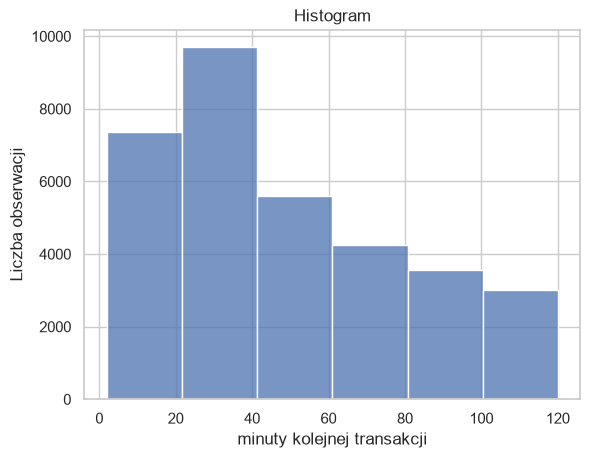

In [56]:
sns.set_theme(style="whitegrid")
sns.histplot(first_non_transport["minutes_to_non_transport"], bins=6)

plt.xlabel("minuty kolejnej transakcji")
plt.ylabel("Liczba obserwacji")
plt.title("Histogram")

plt.show()

In [62]:
first_non_transport.to_csv("first_non_transport.csv", index=False)